# moba `-L` tuning, stage 1: the stability boundary (α_min) — phantom v2, coronal plane

Stage 1 of the tuning plan in `Recon_MOBA_V2.ipynb` (section 18), approved by the researcher:
**how low can the minimum regularisation α_min (`-j`) go before Newton steps diverge?** V2 uses
0.3 conservatively (0.1 diverged in 6 of 26 screened slice runs on phantom v1). Lower α_min
means less smoothing, so less lesion/GM bias and more noise.

Everything else is V2: `moba -L -l1 -i 10 -C 100 --sobolev_a 220`, fixed noise-referenced
scaling (`--scale_data 4.545/σ`, `--scale_psf` = moba's PSF normalisation), slice-wise along the
readout, echo groups combined as T1 = 1/mean(R1*). Data: **synthetic phantom only**.

**Phantom v2** (`recon-comparison` f2840be, merged here): WM 250-300 ms, GM 310-370 ms (bell-
shaped within tissue), lesions 357.5 / 192.5 ms (±30 % of the WM mid-range 275 ms), and centred
partial-volume truth maps (in v1 the lesion evaluation masks were offset by 0.375 voxel through-
plane). All numbers here are on v2 and are not comparable one-to-one with V2's (v1) numbers.

| step | what | section |
|---|---|---|
| 0 | phantom v2: the tissue T1 distributions | 3 |
| 1 | screen: α_min ∈ {0.1, 0.15, 0.2, 0.25, 0.3}, 13 readout slices × 2 echo groups | 4 |
| 2 | full coronal planes for 0.3 and every value that passes, per-slice convergence | 5 |
| 3 | phantom numbers per α_min (bias vs ideal), T1 histograms | 6 |
| 4 | images for visual assessment: T1 maps, differences, lesion zooms | 7 |
| 5 | adaptive fallback; `-R 3` | 8 |
| 6 | what these maps are (geometry) and the decision | 9-10 |

**Decision rule (agreed in the plan):** the smallest α_min with no flagged slice run (raw residual >
1.5 × noise floor) on the full plane, plus one grid step of margin — or the adaptive fallback if
the boundary is slice-specific and a lower α_min clearly reduces lesion bias. The researcher
judges the images.

## 1. Environment

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

os.environ.setdefault('BART_TOOLBOX_PATH', str(Path('~/bart').expanduser()))
REPO = Path.cwd()
sys.path.insert(0, str(REPO / 'synth'))
sys.path.insert(0, str(REPO / 'moba_dev'))
import pipeline_utils as pu
from phantom import load_scans, TISSUE, LESIONS
import diag_slice as ds              # single-readout-slice harness (cached)
import moba_plane as mp              # full-plane slice-wise moba (cached)
import figures as F                  # comparison figures
import run_stage1 as S1              # the stage-1 settings (same as the runner)

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'

## 2. Configuration

The grid and options come from `moba_dev/run_stage1.py`, which ran the heavy parts in the
background; every result is cached (single slices in `<phantom>/moba/diag/cache_<fingerprint>`,
full planes in `<phantom>/moba/`), keyed by the options and by the **phantom fingerprint** (a
hash of `phantom_config.json`), so a different phantom version can never reuse them.

In [2]:
PHANTOM_DIR = ds.PHANTOM_DIR
PROC_DIR = PHANTOM_DIR / 'moba'
PLANE = S1.PLANE
scans = load_scans(PHANTOM_DIR)[PLANE]
info = scans[pu.REF_TI_IDX]['info']
SP = pu.spacing_of(info); ASP = SP[0] / SP[1]
truth = dict(np.load(PHANTOM_DIR / f'truth_{PLANE}.npz'))
head = truth['label'] >= 3
SCALING = S1.screen_scaling()
print('phantom', PHANTOM_DIR, '| fingerprint', ds.phantom_fingerprint(), '| plane', PLANE, info['matrix'], 'voxel (mm)',
      tuple(round(s, 2) for s in SP))
print('tissues (ms):', {TISSUE[l][0]: TISSUE[l][1] for l in (3, 4, 5, 6, 7)})
print('base options:', S1.BASE, '| scaling:', SCALING, '| screen alpha_min:', S1.J_SCREEN)

phantom /root/work/phantom | fingerprint 7ff92781 | plane COR [112, 100, 44] voxel (mm) (1.79, 1.8, 5.0)
tissues (ms): {'CSF': (3400.0, 3700.0), 'GM': (310.0, 370.0), 'WM': (250.0, 300.0), 'lesion_long': (357.5, 357.5), 'lesion_short': (192.5, 192.5)}
base options: -L -l1 -i 10 -C 100 --sobolev_a 220 | scaling: --scale_data 45.7869 --scale_psf 17.971312 | screen alpha_min: (0.1, 0.15, 0.2, 0.25, 0.3)


## 3. Phantom v2: tissue T1 distributions

The researcher's correction: in healthy tissue both WM and GM follow a bell-shaped distribution,
WM within 250-300 ms and GM within 310-370 ms. Phantom v2 keeps the smooth spatial T1 field of
v1 and maps it onto these ranges, which gives a bell with SD ≈ 15 % of the range (bounds at
≈ ±3 SD). **Note:** when asked how the bounds should relate to the bell, the researcher chose
"bounds = ±2 SD" (SD = range/4, WM 12.5 ms, GM 15 ms); v2 as pushed is narrower (below). All
methods must use one phantom, so this stage uses v2 as pushed; a change belongs on
`recon-comparison`.

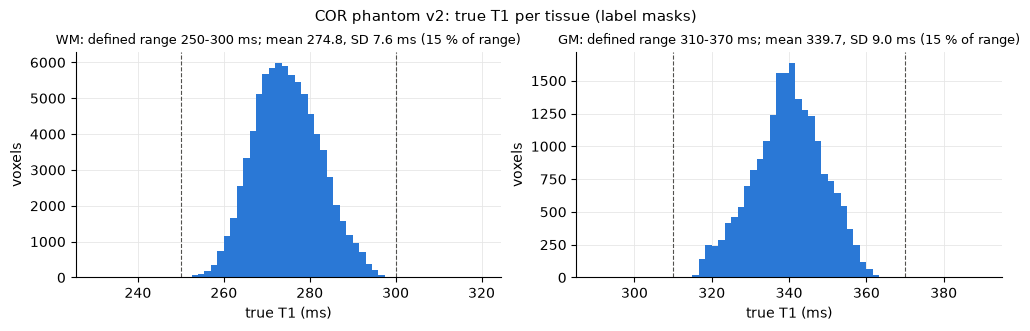

In [3]:
F.truth_histograms(truth, f'{PLANE} phantom v2: true T1 per tissue (label masks)'); plt.show()

## 4. Screen: 13 readout slices × 2 echo groups per α_min

Single readout slices x = 8, 16, …, 104 (bottom to top of the head), both echo groups, each
α_min. A slice run is **flagged** when its raw-data residual exceeds 1.5 × its noise floor
(V2 section 7: converged fits sit at 0.85-0.9 ×, diverged ones at 3-90 ×).

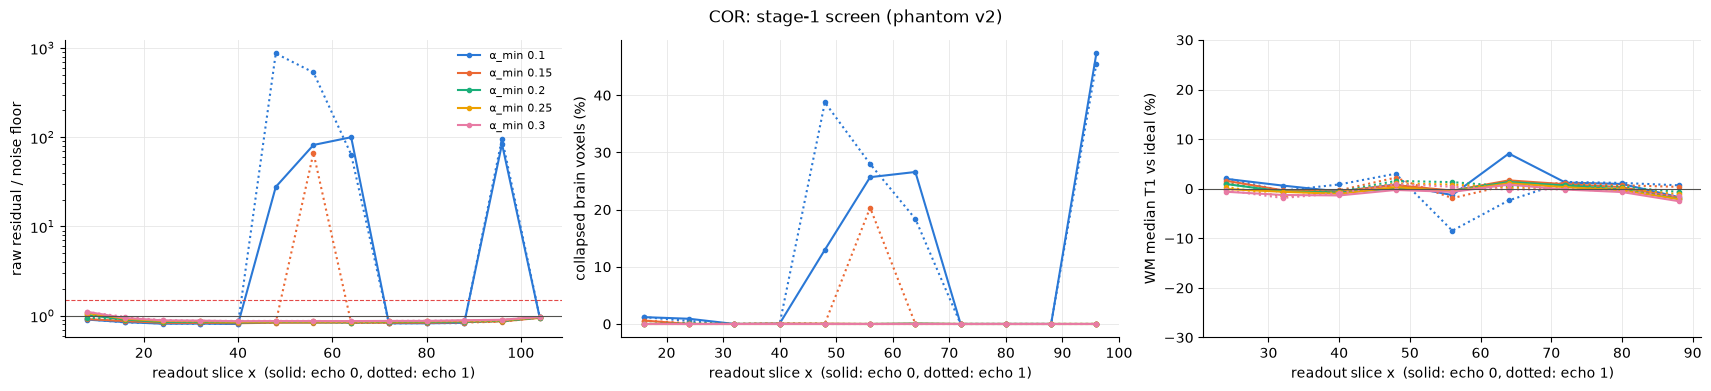

alpha_min  flagged  res/noise median    max  flagged runs
     0.10     8/26              0.85 867.53  ['x=48 e0', 'x=56 e0', 'x=64 e0', 'x=96 e0', 'x=48 e1', 'x=56 e1', 'x=64 e1', 'x=96 e1']
     0.15     1/26              0.84  66.76  ['x=56 e1']
     0.20     0/26              0.85   1.02  []
     0.25     0/26              0.87   1.08  []
     0.30     0/26              0.88   1.11  []
passing: [0.2, 0.25, 0.3]


In [4]:
scr = {j: S1.screen(j, SCALING) for j in S1.J_SCREEN}


def plot_screen(scr, title):
    fig, ax = plt.subplots(1, 3, figsize=(17, 3.8), layout='constrained')
    for (j, rr), col in zip(scr.items(), F.SERIES8):
        for e, ls in ((0, '-'), (1, ':')):
            r_e = [r for r in rr if r['e'] == e]
            x = [r['x'] for r in r_e]
            ax[0].semilogy(x, [r['final_res'] / r['noise_floor'] for r in r_e], 'o' + ls, ms=3, color=col,
                           label=f'α_min {j}' if e == 0 else None)
            ax[1].plot(x, [100 * r['rows']['collapsed_frac'] for r in r_e], 'o' + ls, ms=3, color=col)
            ax[2].plot(x, [100 * (r['rows']['WM']['med'] / r['rows']['WM']['ideal'] - 1) if 'WM' in r['rows'] else np.nan
                           for r in r_e], 'o' + ls, ms=3, color=col)
    ax[0].axhline(1, color='#52514e', lw=0.8); ax[0].axhline(S1.FLAG, color='#e34948', lw=0.8, ls='--')
    ax[0].set_ylabel('raw residual / noise floor'); ax[1].set_ylabel('collapsed brain voxels (%)')
    ax[2].set_ylabel('WM median T1 vs ideal (%)'); ax[2].set_ylim(-30, 30); ax[2].axhline(0, color='#52514e', lw=0.8)
    for a in ax:
        a.set_xlabel('readout slice x  (solid: echo 0, dotted: echo 1)'); F._style(a)
    ax[0].legend(fontsize=8, frameon=False)
    fig.suptitle(title); plt.show()


plot_screen(scr, f'{PLANE}: stage-1 screen (phantom v2)')
print(f"{'alpha_min':>9s} {'flagged':>8s} {'res/noise median':>17s} {'max':>6s}  flagged runs")
for j, rr in scr.items():
    q = np.array([r['final_res'] / r['noise_floor'] for r in rr])
    bad = [f"x={r['x']} e{r['e']}" for r in rr if r['final_res'] > S1.FLAG * r['noise_floor']]
    print(f'{j:9.2f} {len(bad):5d}/{len(rr)} {np.median(q):17.2f} {q.max():6.2f}  {bad}')
PASSING = [j for j, rr in scr.items() if S1.n_flagged(rr) == 0]
print('passing:', PASSING)

## 5. Full coronal planes: per-slice convergence

Three full planes (the approved budget): α_min = 0.3 (the V2 baseline, now on phantom v2), the
**lowest value that passed** the screen, and the **next grid value below it**, which failed the
screen in a few slices — the case the adaptive fallback (section 8) is for, and the one that
shows what less regularisation buys. All 112 readout slices × 2 echo groups each; the full plane
is the real stability test (224 slice runs vs 26 in the screen).

full planes for alpha_min [0.3, 0.2, 0.15]
alpha_min 0.3: echo 0:  15.9 min, res/noise median 0.88, max 1.27 (x=14), flagged 0 []
alpha_min 0.3: echo 1:  14.9 min, res/noise median 0.88, max 1.24 (x=14), flagged 0 []


alpha_min 0.2: echo 0:  23.8 min, res/noise median 0.86, max 1.10 (x=13), flagged 0 []
alpha_min 0.2: echo 1:  23.1 min, res/noise median 0.86, max 1.10 (x=102), flagged 0 []


alpha_min 0.15: echo 0:  22.8 min, res/noise median 0.84, max 5830.02 (x=94), flagged 6 [54, 59, 62, 94, 102, 103]
alpha_min 0.15: echo 1:  13.4 min, res/noise median 0.84, max 1170.32 (x=94), flagged 9 [53, 54, 55, 56, 57, 59, 62, 94, 102]


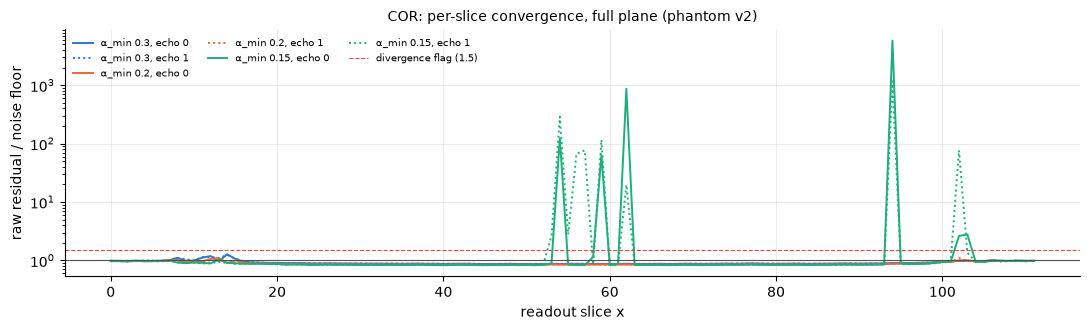

In [5]:
PLANE_J = S1.planes_to_run(PASSING)
print('full planes for alpha_min', PLANE_J)
rec = {}
for j in PLANE_J:
    rec[j] = [mp.moba_recon(scans, e, PLANE, S1.opts_j(j), PHANTOM_DIR, PROC_DIR,
                            progress=PROC_DIR / 'moba_progress.log')[0] for e in (0, 1)]
    for e, r in enumerate(rec[j]):
        q = r['final_res'] / r['noise_floor']
        print(f"alpha_min {j}: echo {e}: {float(r['runtime_s']) / 60:5.1f} min, res/noise median {np.median(q):.2f}, "
              f"max {q.max():.2f} (x={int(np.argmax(q))}), flagged {int((q > S1.FLAG).sum())} {np.flatnonzero(q > S1.FLAG).tolist()}")
F.slice_qc({f'α_min {j}': rec[j] for j in PLANE_J}, f'{PLANE}: per-slice convergence, full plane (phantom v2)'); plt.show()

## 6. Phantom numbers per α_min

T1 = 1/mean(R1*) over the two echo groups, NaN outside the head label (≥ 3), evaluated with
`pu.evaluate_t1` (eroded tissue masks; each lesion: voxels holding ≥ half its peak partial-volume
fraction). **Bias vs ideal** (the resolution-limited, fully sampled, noise-free reference) is the
reconstruction's own error. A setting with flagged slices is also shown "+ fallback" (flagged
slices re-done at α_min 0.3, section 8). Below the table: medians and robust SD (1.4826 × MAD) in WM
and GM, and the histograms per setting.

region                 n   true  ideal              α 0.3            α 0.2           α 0.15        α 0.15+fb
WM                 70965  274.8  274.7    274.8 ( +0.0%)  276.9 ( +0.8%)  331.7 (+20.7%)  278.4 ( +1.3%)
GM                  3750  339.7  339.3    329.4 ( -2.9%)  335.9 ( -1.0%) 2205.6 (+550.2%)  338.9 ( -0.1%)
lesion 1 (10 mm)      32  357.5  340.7    335.3 ( -1.6%)  343.0 ( +0.7%)  348.3 ( +2.2%)  348.3 ( +2.2%)
lesion 2 (6 mm)        7  357.5  336.2    320.9 ( -4.5%)  318.3 ( -5.3%)  316.1 ( -6.0%)  316.1 ( -6.0%)
lesion 3 (4 mm)        2  357.5  331.9    333.6 ( +0.5%)  349.3 ( +5.2%)  359.5 ( +8.3%)  359.5 ( +8.3%)
lesion 4 (2 mm)        2  357.5  283.5    305.4 ( +7.7%)  309.8 ( +9.3%)  315.4 (+11.2%)  315.4 (+11.2%)
lesion 5 (10 mm)      32  192.5  207.0    214.1 ( +3.4%)  214.1 ( +3.4%)  214.6 ( +3.7%)  214.6 ( +3.7%)
lesion 6 (6 mm)        7  192.5  206.9    227.1 ( +9.8%)  225.3 ( +8.9%)  223.6 ( +8.1%)  223.6 ( +8.1%)
lesion 7 (4 mm)        2  192.5  214.8    231.3 ( 

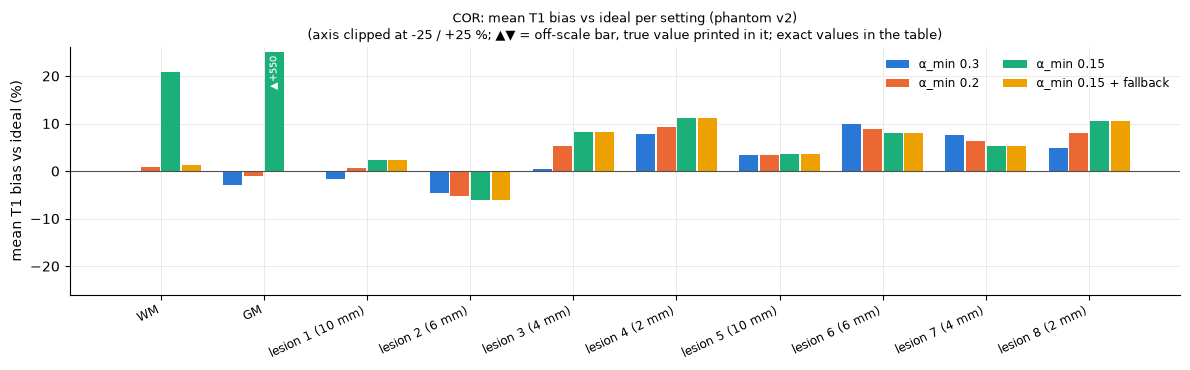

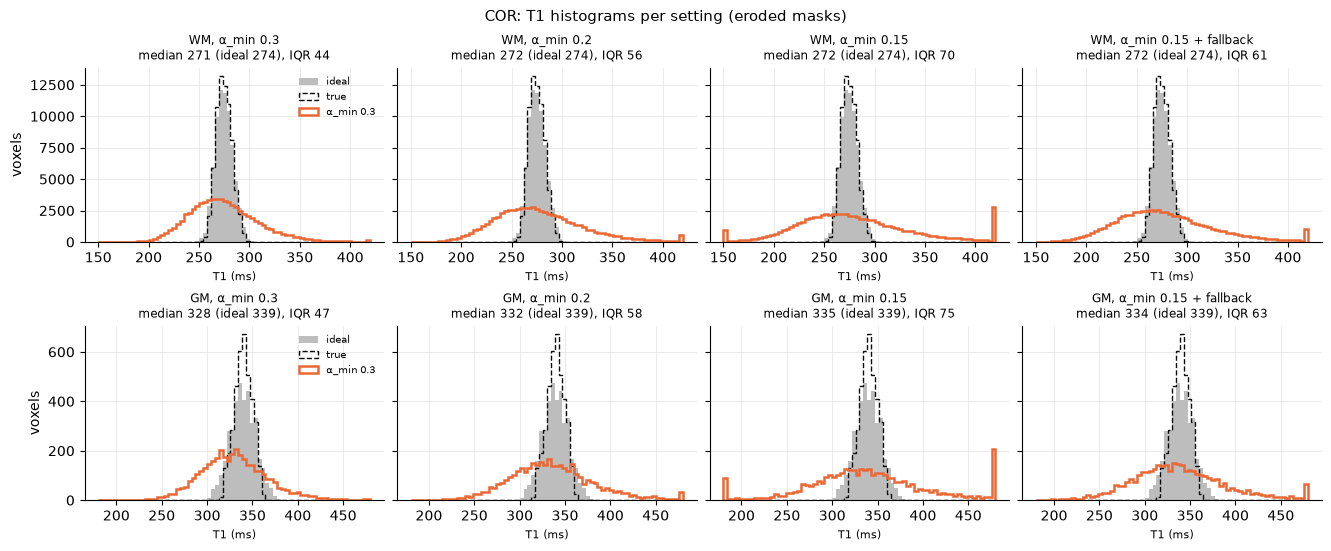

In [6]:
def fallback(j):
    # alpha_min j, with every readout slice the residual QC flags (worst of the two echo groups)
    # replaced by the alpha_min 0.3 slice (section 8)
    q = np.maximum(*(r['final_res'] / r['noise_floor'] for r in rec[j]))
    bad = np.flatnonzero(q > S1.FLAG)
    maps = [r['maps'].copy() for r in rec[j]]
    for e in (0, 1):
        maps[e][bad] = rec[0.3][e]['maps'][bad]
    return 1000 * mp.t1_from(maps, head), bad


T1, FB = {}, {}                                   # setting label -> T1 map (ms); alpha_min -> replaced slices
for j in PLANE_J:
    T1[f'α_min {j}'] = 1000 * mp.t1_from([r['maps'] for r in rec[j]], head)
    if j != 0.3:
        t, FB[j] = fallback(j)
        if len(FB[j]):
            T1[f'α_min {j} + fallback'] = t
rows = {k: pu.evaluate_t1(v / 1000, truth) for k, v in T1.items()}
llr_f = PHANTOM_DIR / f'llr_{PLANE}.npz'
if llr_f.exists():
    rows['LLR'] = pu.evaluate_t1(np.load(llr_f)['T1_s'], truth)
short = lambda k: k.replace('α_min ', 'α ').replace(' + fallback', '+fb')
cols = list(rows)
r0 = rows[cols[0]]
print(f"{'region':18s} {'n':>5s} {'true':>6s} {'ideal':>6s}  " + ''.join(f"{short(c):>17s}" for c in cols))
for i, r in enumerate(r0):
    if r['region'] == 'CSF':
        continue
    print(f"{r['region']:18s} {r['n']:5d} {r['true_ms']:6.1f} {r['ideal_ms']:6.1f}  "
          + ''.join(f"{rows[c][i]['est_ms']:7.1f} ({rows[c][i]['bias_vs_ideal_pct']:+5.1f}%)" for c in cols))
print('cells: mean T1 (ms) and bias vs ideal; CSF omitted (fails for every setting, see V2 report);'
      ' +fb = flagged slices re-done at alpha_min 0.3')
masks = F.tissue_masks(truth)
for name in ('WM', 'GM'):
    m = masks[name]
    print(f'{name}: ideal median {np.median(truth["T1_ideal_ms"][m]):.1f} | ' + ' | '.join(
        f"{short(k)}: median {np.nanmedian(v[m]):.1f}, robust SD {1.4826 * np.nanmedian(np.abs(v[m] - np.nanmedian(v[m]))):.1f}"
        for k, v in T1.items()))
F.bias_bars(rows, f'{PLANE}: mean T1 bias vs ideal per setting (phantom v2)'); plt.show()
F.hist_by_setting(T1, truth, f'{PLANE}: T1 histograms per setting (eroded masks)'); plt.show()

## 7. Images for visual assessment

Coronal in-plane slices (1.8 × 1.8 mm; rows = settings, first row the ideal), at the mid slice and
the slices through the lesion centres; shared window. "α_min 0.15" is shown as reconstructed
(the diverged readout slices appear as broken horizontal lines) and "+ fallback" with those slices
re-done at 0.3 (section 8). Then the same as differences from the ideal,
a zoom on the lesion region, and the lesion panel (zoomed central slice of each lesion, per-voxel
T1 inside each lesion mask).

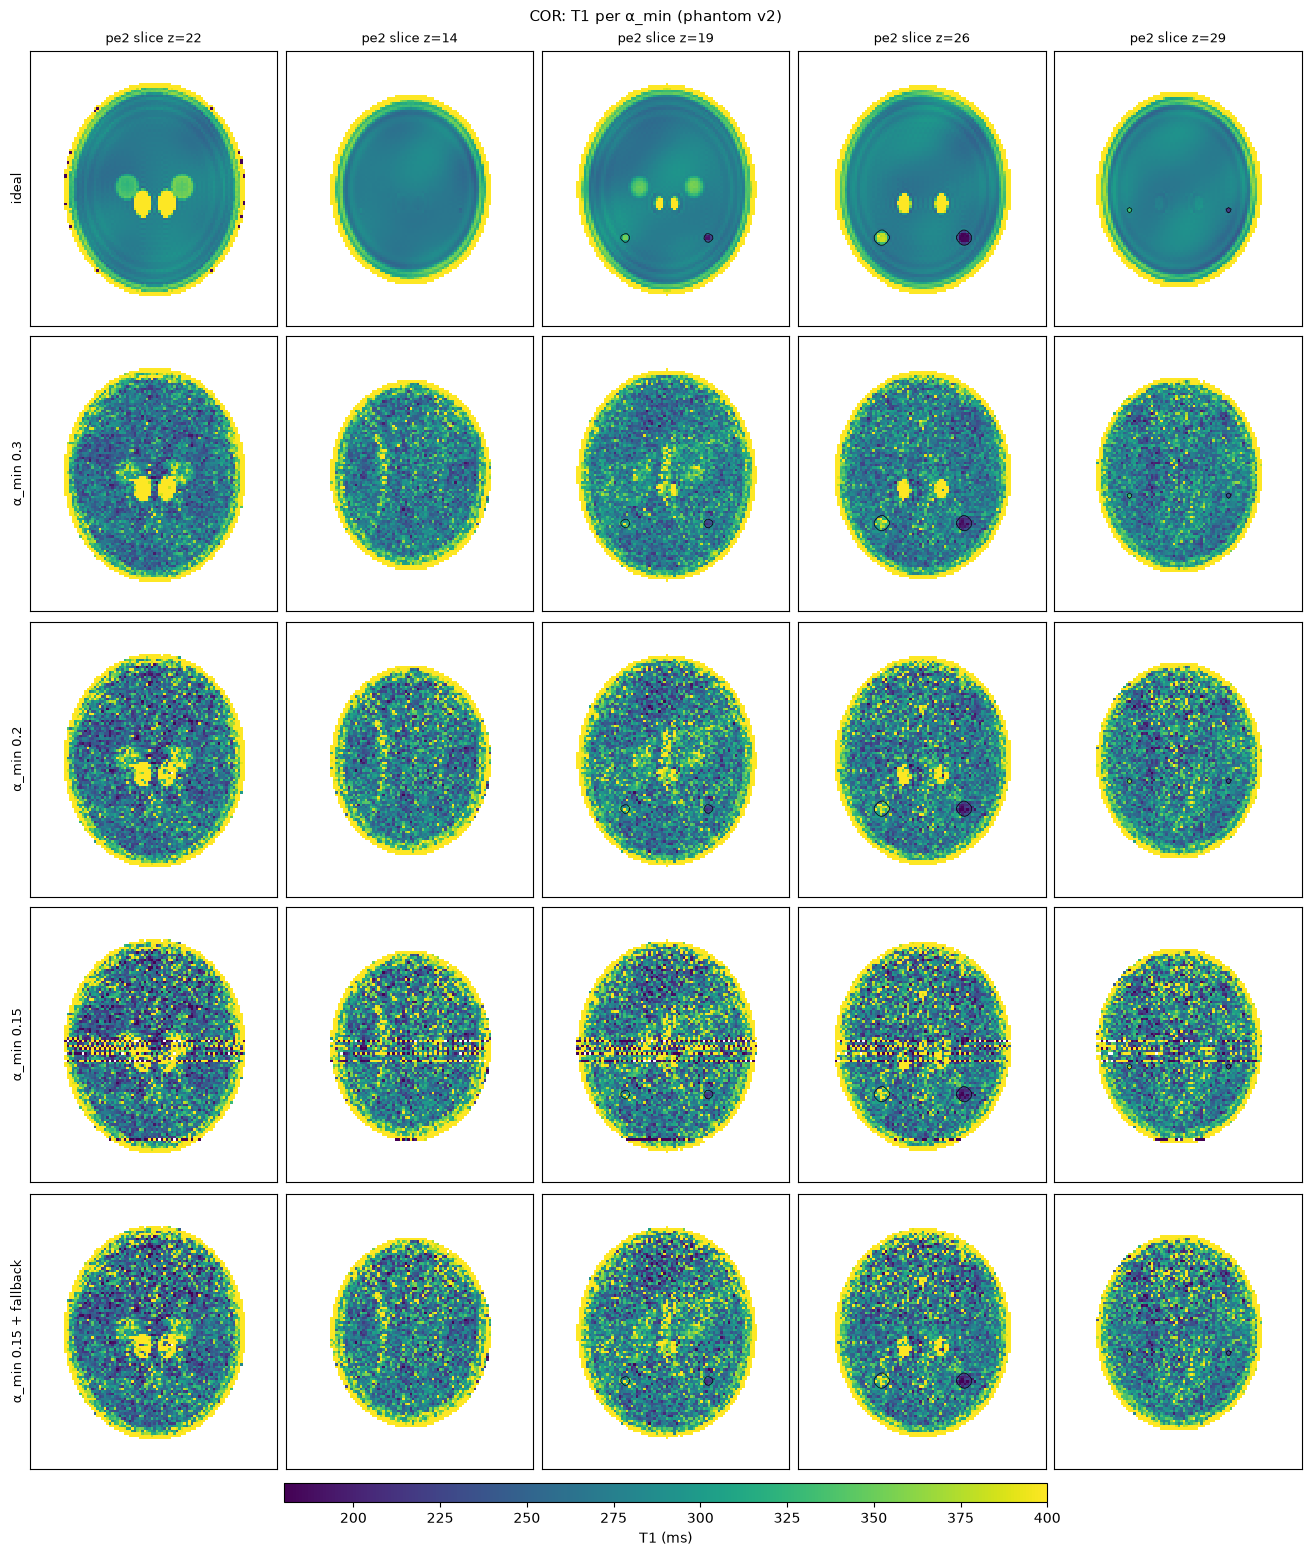

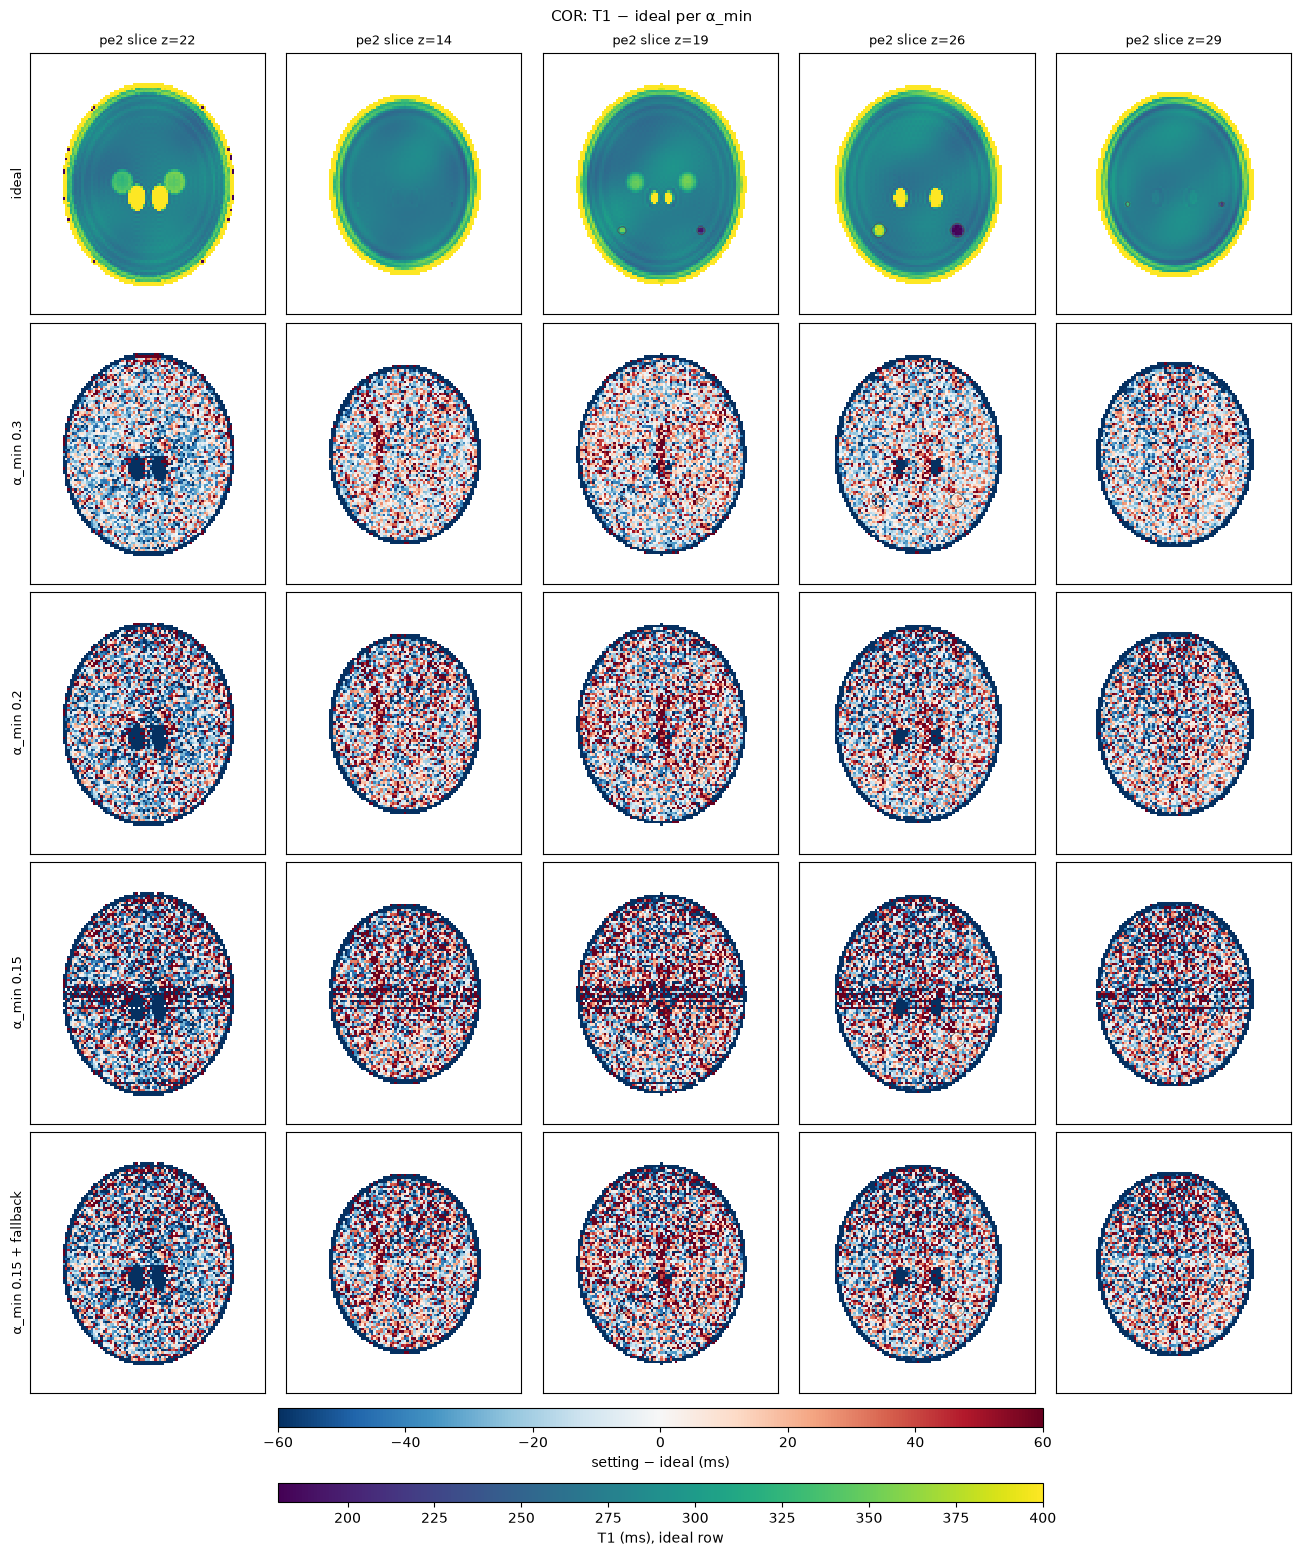

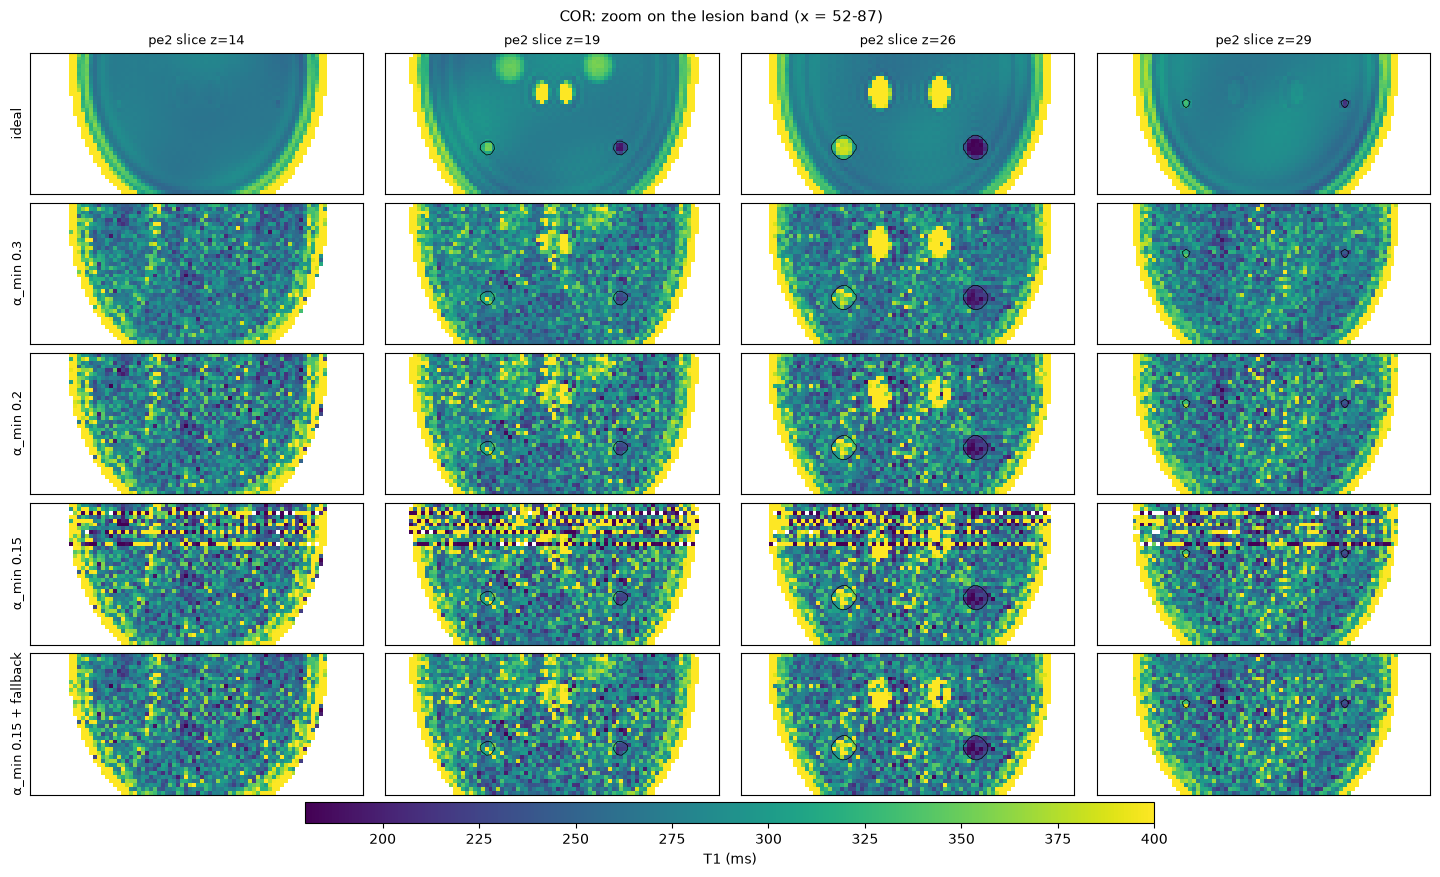

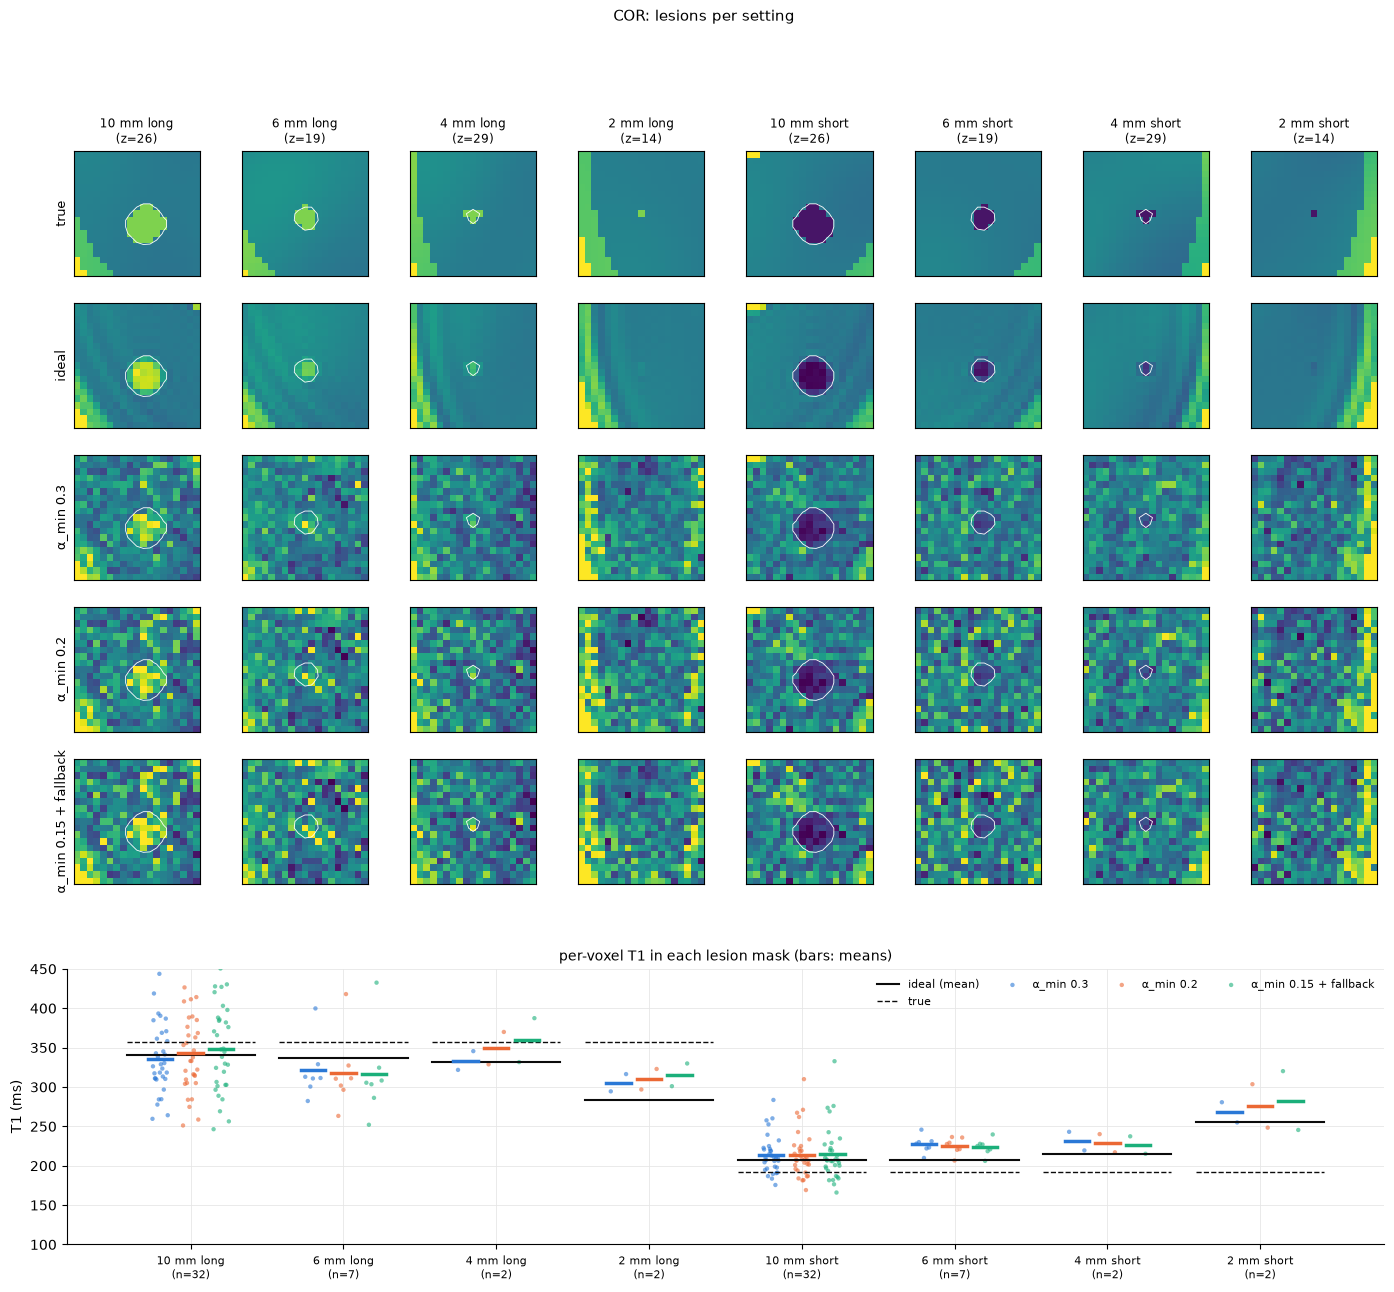

In [7]:
LZ = sorted(set(z for _, _, z in F.lesion_slices(truth)))
SL = [truth['label'].shape[2] // 2] + LZ
vols = T1
F.sweep_grid(vols, truth, SL, SP, f'{PLANE}: T1 per α_min (phantom v2)'); plt.show()
F.sweep_grid(vols, truth, SL, SP, f'{PLANE}: T1 − ideal per α_min', diff=True); plt.show()
xs_ = [x for x, _, _ in F.lesion_slices(truth)]
crop = (slice(min(xs_) - 12, max(xs_) + 13), slice(8, truth['label'].shape[1] - 8))
F.sweep_grid(vols, truth, LZ, SP, f'{PLANE}: zoom on the lesion band (x = {crop[0].start}-{crop[0].stop - 1})', crop=crop); plt.show()
jst = min(j for j in PLANE_J if len(FB.get(j, [])) == 0)          # lowest alpha_min with no flagged slice
keys = list(dict.fromkeys(['α_min 0.3', f'α_min {jst}'] + [k for k in T1 if k.endswith('fallback')]))[:3]
sel = {k: T1[k] for k in keys}
F.lesion_panel(sel, truth, SP, f'{PLANE}: lesions per setting'); plt.show()

## 8. Adaptive fallback and `-R 3`

**Adaptive fallback:** reconstruct at a lower α_min and replace only the slices the residual QC
flags by the α_min = 0.3 slices. With full planes at both values this costs nothing extra: the
table shows, per lower α_min, how many slices would be replaced and the resulting numbers.
**`-R 3`:** faster decay of α towards α_min (more Newton steps at the floor) at the lowest passing
value, screen only.

alpha_min 0.2: 0 of 112 readout slices flagged and re-done at 0.3: []
alpha_min 0.15: 10 of 112 readout slices flagged and re-done at 0.3: [53, 54, 55, 56, 57, 59, 62, 94, 102, 103]
   bias vs ideal with fallback: WM +1.3%, GM -0.1%, lesion 1 +2.2%, lesion 2 -6.0%, lesion 3 +8.3%, lesion 4 +11.2%, lesion 5 +3.7%, lesion 6 +8.1%, lesion 7 +5.3%, lesion 8 +10.6%


-j 0.2 -R 3 screen: flagged 2/26, res/noise median 0.85, max 113.60


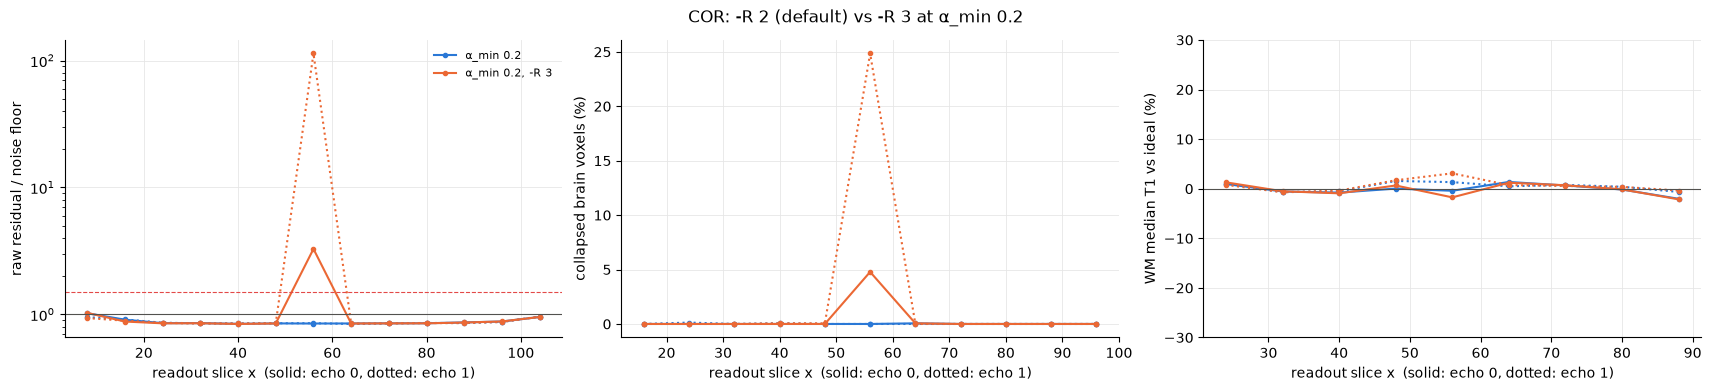

In [8]:
for j, bad in FB.items():
    print(f'alpha_min {j}: {len(bad)} of {truth["label"].shape[0]} readout slices flagged and re-done at 0.3: {bad.tolist()}')
    if len(bad):
        rr = rows[f'α_min {j} + fallback']
        print('   bias vs ideal with fallback: ' + ', '.join(f"{r['region'].split(' (')[0]} {r['bias_vs_ideal_pct']:+.1f}%"
                                                      for r in rr if r['region'] != 'CSF'))
if PASSING:
    jl = min(PASSING)
    r3 = S1.screen(jl, SCALING, extra=' -R 3', tag=f'j{jl} R3')
    q = np.array([r['final_res'] / r['noise_floor'] for r in r3])
    print(f'-j {jl} -R 3 screen: flagged {S1.n_flagged(r3)}/{len(r3)}, res/noise median {np.median(q):.2f}, max {q.max():.2f}')
    plot_screen({f'{jl}': scr[jl], f'{jl}, -R 3': r3}, f'{PLANE}: -R 2 (default) vs -R 3 at α_min {jl}')

## 9. What these T1 maps are

Each `moba` run gives a **per-plane T1 map on that plane's own reconstruction grid**: here the
coronal plane, 112 × 100 × 44 voxels of 1.8 (S/I, readout) × 1.8 (L/R) × 5 mm (A/P). "In-plane"
(the coronal 1.8 × 1.8 mm view) is the native resolution; through-plane it is 5 mm. The map is
built slice-wise along the readout (S/I): each readout position is an independent 2D problem
(L/R × A/P), which is exact because the readout is fully sampled and Cartesian. Nothing here is
isotropic yet: combining the three planes into the 1.8 mm isotropic T1 map (3-plane super-
resolution) is a later step (`Recon_MOBA_V2.ipynb` section 17); the axial and sagittal planes
are not reconstructed in this stage.

## 10. Result and decision (stage 1)

**Phantom v2, coronal plane, all other options as V2.** Every number below is from the outputs
above.

### Stability boundary

| α_min | screen: flagged slice runs (of 26) | full plane: flagged slice runs (of 224) | worst residual / noise floor |
|---|---|---|---|
| 0.10 | 8 (x = 48, 56, 64, 96 in **both** echo groups) | – | 868 (screen) |
| 0.15 | 1 (x = 56, echo 1) | **15** (10 distinct slices) | 5830 |
| 0.20 | 0 | **0** | 1.10 |
| 0.25 | 0 | – (screen only) | 1.08 (screen) |
| 0.30 | 0 | **0** | 1.27 |

* The boundary lies **between 0.15 and 0.2** on phantom v2 (on v1 it was between 0.1 and 0.3,
  not resolved further). At 0.2 every one of the 224 slice runs converges.
* **The screen under-calls instability**: at 0.15 it flagged 1 of 26 slice runs, the full plane
  15 of 224 (6 in echo 0, 9 in echo 1; 10 distinct slices: x = 53-57, 59, 62, 94, 102, 103).
  A 13-slice screen is a cheap first filter, not a stability proof; the full-plane residual QC is
  the real test.
* Divergence is **slice-specific, not random**: at 0.1 the same four slices fail in both echo
  groups (independent noise), and the 0.15 failures cluster in the same region
  (x = 54-64, 94, and two scalp-level slices). Anatomy/coil geometry decide where the
  linearised steps go wrong.

### What lower α_min buys (0.2 vs 0.3)

| region | ideal (ms) | α_min 0.3 | α_min 0.2 |
|---|---|---|---|
| WM | 274.7 | 274.8 (+0.0 %) | 276.9 (+0.8 %) |
| GM | 339.3 | 329.4 (**−2.9 %**) | 335.9 (**−1.0 %**) |
| lesion 10 mm, long T1 | 340.7 | −1.6 % | +0.7 % |
| lesion 6 mm, long | 336.2 | −4.5 % | −5.3 % |
| lesion 4 mm, long (2 voxels) | 331.9 | +0.5 % | +5.2 % |
| lesion 2 mm, long (2 voxels) | 283.5 | +7.7 % | +9.3 % |
| lesion 10 mm, short T1 | 207.0 | +3.4 % | +3.4 % |
| lesion 6 mm, short | 206.9 | +9.8 % | +8.9 % |
| lesion 4 mm, short (2 voxels) | 214.8 | +7.7 % | +6.4 % |
| lesion 2 mm, short (2 voxels) | 255.7 | +4.8 % | +7.9 % |
| WM robust SD (ms) | – | 32.4 | 40.9 (+26 %) |
| GM robust SD (ms) | – | 34.6 | 42.9 |

**0.15** converges in most slices but diverges in 10 (above). Without a fallback those slices ruin
the means (WM +20.7 %, GM +550 % vs ideal) although the medians stay sensible (WM 272.1, GM 334.9 ms;
robust SD 50.5 / 55.3 ms). With the fallback (next paragraph) its numbers are WM +1.3 %, GM −0.1 %,
lesions +2.2 / −6.0 / +8.3 / +11.2 % (long T1, 10/6/4/2 mm) and +3.7 / +8.1 / +5.3 / +10.6 % (short):
GM improves further, the lesions do not, and the noise rises again (WM robust SD 44.7 ms with the
fallback, 50.5 ms as reconstructed, vs 40.9 at 0.2).

Going from 0.3 to 0.2 removes most of the GM bias (−2.9 → −1.0 %) at ~26 % more noise; the
lesion means hardly move (the 10 mm lesions are within 2 % of ideal at both; the 4 and 2 mm
lesions now hold only 2 voxels each in v2's centred masks, so their ± 5 % differences are noise).
Visually (section 7) the maps at 0.2 are slightly noisier, not sharper: α_min is a weak knob for
image quality, because it is bounded below by stability. **Noise, not regularisation bias, is
what limits these maps now** (WM robust voxel SD 12-15 % of T1; the 4 and 2 mm lesions are not visible).

**Adaptive fallback** (re-do flagged slices at 0.3, section 8): at 0.2 it never triggers (0 slices);
at 0.15 it replaces 10 of 112 readout slices and turns a broken map into a usable one. It works as
a safety net, but lowering α_min below 0.2 buys only GM accuracy (−1.0 → −0.1 %) at 10-25 % more
noise and no lesion gain, so the agreed exception ("a lower α_min clearly reduces lesion bias")
does not apply.

**`-R 3`** (α decays 3× per Newton step instead of 2×, so more steps run at α_min) at 0.2:
**2 of 26** screened slice runs diverge (0 with the default `-R 2`). Faster decay destabilises; keep
`-R 2`.

### Decision (for the researcher)

By the agreed rule — smallest α_min with no flagged slice on the full plane (0.2), plus one grid
step of margin — the choice is **α_min = 0.25**. The alternative the rule allows is **0.2 with
the residual-QC fallback** (any slice above 1.5 × its noise floor is re-done at 0.3): it keeps
0.2's lower GM bias and gets its margin per slice from the QC instead of globally; on this phantom
the fallback would never trigger at 0.2. My recommendation is **0.2 + QC fallback**, because the
QC is also the safeguard needed on real data, where the boundary will move. Either way, stage 2
should decouple the regularisation *strength* from stability: `--l1val` scales only the
wavelet threshold, so it can trade noise against bias at a fixed, stable α_min.

### Next: stage 2 (proposal, awaits approval)

* **2a, wavelet strength at α_min 0.2 (+ QC fallback):** `--l1val` ∈ {0.5, 2, 4} (1 = current).
  Screen (≈ 5 min each, stability) then full planes for the values that pass (≈ 35-45 min
  each): numbers, maps, histograms as here. Expected: higher `l1val` lowers the noise and
  raises partial-volume-like lesion/GM bias; the researcher picks the trade-off by eye.
* **2b, regulariser type:** total variation on the maps (`-r T:6:0:λ`, ADMM path, 2-3 λ) vs
  the joint wavelet; screen first.
* LLR on phantom v2 is not re-run here (the brief's table is v1); for a side-by-side in stage 2
  it would need one run (≈ 35 min).